# Question 1

Load the data from the file *trajectory.csv*. The data consists of three rows representing a trajectory. The first row represents time, the second row represents the $x$-coordinate at each timestep, and the third row represents the $y$-coordinate.

**Q1 a (3 marks)**

Plot the $x$-coordinate against time (i.e., t-x figure) and also for the $y$-coordinate (i.e., t-y figure). Also plot the trajectory in 2D (i.e., x-y figure).

You need to respectively use variables 't', 'x', 'y' to represent time, x-coordinate, and y-coordinate, as these variables will be needed in other questions.

Include clear titles, axis labels, and legends for all figures.

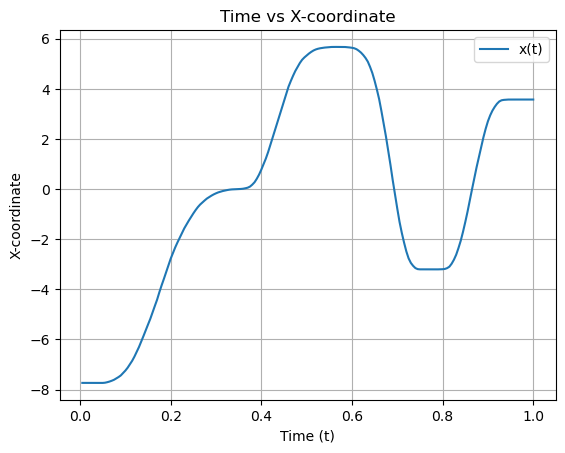

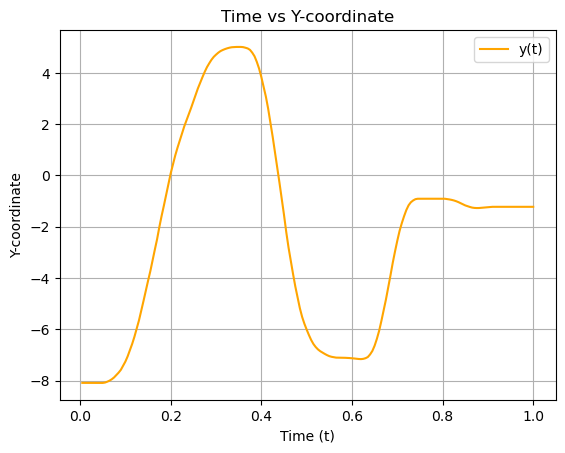

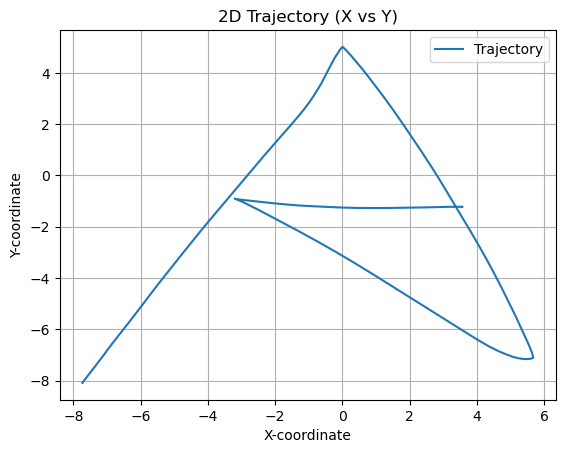

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# read from trajectory.csv
data = np.loadtxt("trajectory.csv", delimiter=",", skiprows=1, usecols=range(1, 201))
t = data[0]
x = data[1]
y = data[2]

# plot x coordinate vs time
plt.figure()

plt.plot(t, x, label="x(t)")
plt.title("Time vs X-coordinate")
plt.xlabel("Time (t)")
plt.ylabel("X-coordinate")
plt.legend()
plt.grid()
plt.show()

# plot y coordinate vs time
plt.figure()

plt.plot(t, y, label="y(t)", color="orange")
plt.title("Time vs Y-coordinate")
plt.xlabel("Time (t)")
plt.ylabel("Y-coordinate")
plt.legend()
plt.grid()
plt.show()

# plot x coordinate vs y coordinate
plt.figure()

plt.plot(x, y, label="Trajectory")
plt.title("2D Trajectory (X vs Y)")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.legend()
plt.grid()

plt.show()

### Linear regression using polynomial basis functions

**Q1 b (6 marks)**

Use your `t`, `x`, and `y` variables from Q1 a.

1. Implement `polynomial_basis_function(t, basis_num)` to return a polynomial design matrix.
2. Use linear regression with your basis function (for Q1 b, use `basis_num = 15`) to fit the 2D trajectory data (`x`, `y`). Note that the bias term should be added in your fitting.
3. Generate predicted trajectories for both coordinates across all time points.
4. Plot and compare on the same axes:
   - original `x` and predicted `x` against `t`,
   - original `y` and predicted `y` against `t`,
   - original and predicted trajectories in the `x-y` plane.

Include clear titles, axis labels, and legends for all figures.

In [61]:

def polynomial_basis_function(t, basis_num):
    """
    Compute the polynomial basis function for the given time vector and number of basis functions.

    Parameters:
    t (numpy array): Time vector of shape (N,).
    basis_num (int): Number of polynomial basis functions.

    Returns:
    numpy array: Design matrix of shape (N, basis_num) where each row corresponds to one data sample.
    """
    t=np.asarray(t)
    N=t.shape[0]
    phi=np.zeros((N,basis_num))  # initializing the design matrix with zeros
    for i in range(basis_num): # i=0,1,...,basis_num-1
        phi[:,i]=t**i    # phi[:,0]=t**0=1, phi[:,1]=t**1=t, phi[:,2]=t**2, ...

    return phi
    
    raise NotImplementedError("Please implement the polynomial_basis_function function.")
    


### Fitting the linear regression model using the polynomial basis function

In [62]:
basis_num = 15  # We can change this value to use a different number of basis functions
Phi = polynomial_basis_function(t, basis_num)

# Compute the weights for x and y
w_x = np.linalg.pinv(Phi) @ x
w_y = np.linalg.pinv(Phi) @ y

#Predict the x and y coordinates using the fitted model
x_pred = Phi @ w_x
y_pred = Phi @ w_y

### Plots

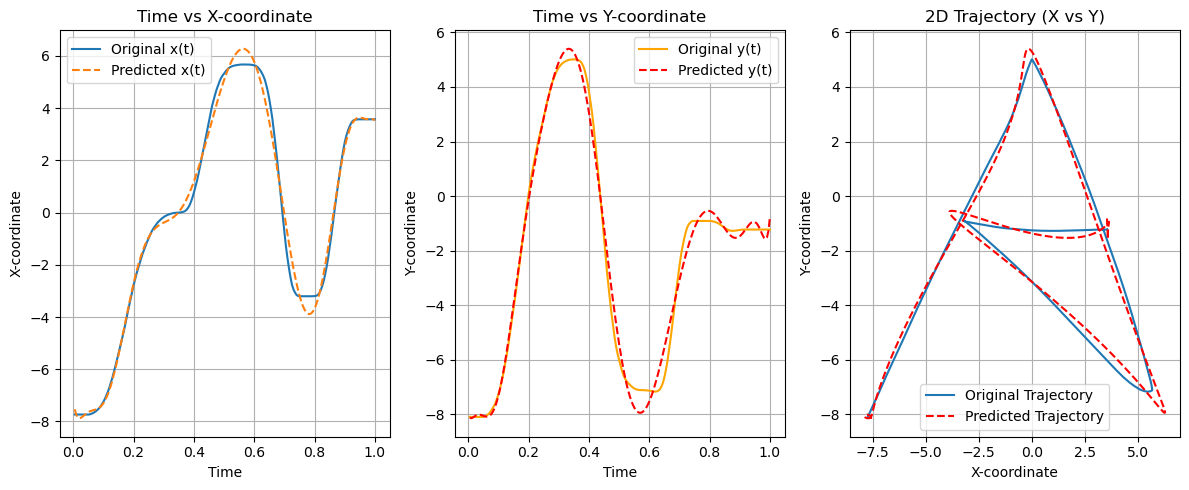

In [63]:
fig,axes=plt.subplots(1,3,figsize=(12,5))

# Plot the original and predicted x coordinate vs time
axes[0].plot(t, x, label="Original x(t)") # Plot original x(t)
axes[0].plot(t, x_pred, label="Predicted x(t)", linestyle="dashed") # Add predicted x(t) to the plot
axes[0].set_title("Time vs X-coordinate")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("X-coordinate")
axes[0].legend()
axes[0].grid()

# Plot the original and predicted y coordinate vs time
axes[1].plot(t, y, label="Original y(t)", color="orange")  # Plot original y(t)
axes[1].plot(t, y_pred, label="Predicted y(t)", linestyle="dashed", color="red")  # Add predicted y(t) to the plot
axes[1].set_title("Time vs Y-coordinate")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Y-coordinate")
axes[1].legend()
axes[1].grid()

# Plot the original and predicted trajectory
axes[2].plot(x, y, label="Original Trajectory")  # Plot original trajectory
axes[2].plot(x_pred, y_pred, label="Predicted Trajectory", linestyle="dashed", color="red") # Add predicted trajectory to the plot
axes[2].set_title("2D Trajectory (X vs Y)")
axes[2].set_xlabel("X-coordinate")
axes[2].set_ylabel("Y-coordinate")
axes[2].legend()
axes[2].grid()
plt.tight_layout()
plt.show()

**Q1 c (3 marks)**

Using the polynomial basis model, plot the fitted trajectories for `basis_num = 2, 5, 10` and briefly compare how fit quality changes as the number of basis functions increases.

Include clear titles, axis labels, and legends for all figures.

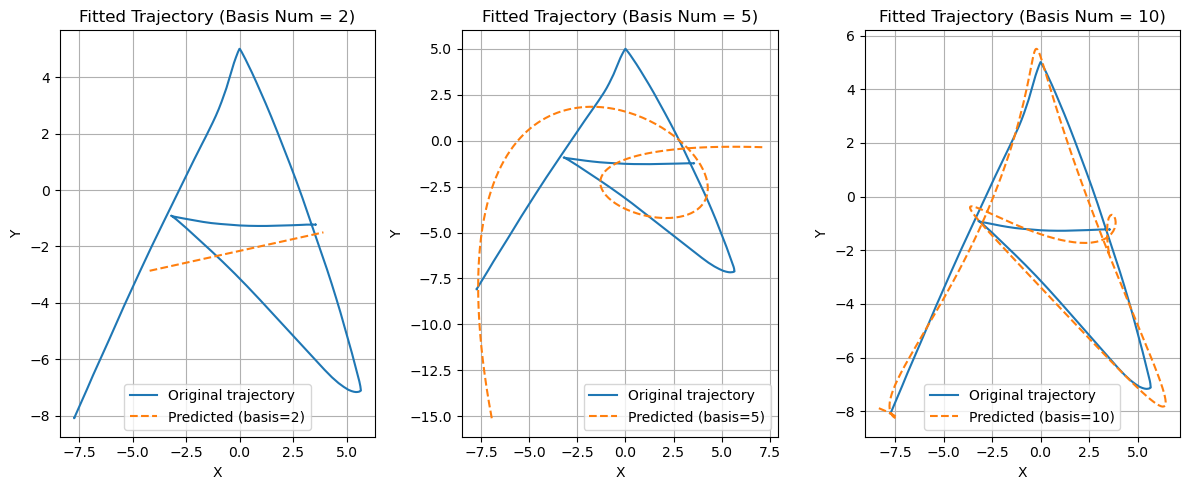

In [64]:
basis_nums = [2, 5, 10]  # creating a list

fig, axes = plt.subplots(1, 3, figsize=(12, 5))  # creating a figure with 1 row and 3 columns of subplots

for i, num in enumerate(basis_nums): # iterating over the list of basis numbers and their corresponding subplot index
    
    Phi = polynomial_basis_function(t, num)
    
    w_x = np.linalg.pinv(Phi) @ x
    w_y = np.linalg.pinv(Phi) @ y
    
    x_pred = Phi @ w_x
    y_pred = Phi @ w_y

    # Plot original
    axes[i].plot(x, y, label="Original trajectory")

    # Plot prediction
    axes[i].plot(x_pred, y_pred, linestyle="--", label=f"Predicted (basis={num})")

    axes[i].set_title(f"Fitted Trajectory (Basis Num = {num})")
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("Y")
    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()

## Effect of Increasing Polynomial Basis Functions
#### The model becomes more flexible as the number of polynomial basis functions rises.
- Basis = 2: The model is too simple and underfits the data. It cannot capture the curved structure of the trajectory.
- Basis = 5: The model begins to poorly capture the overall shape of the trajectory.
- Basis = 10: The model gives a considerably better match and closely resembles the actual trajectory, capturing minute aspects of the motion.
Nevertheless, overfitting—a situation in which the model begins to match noise rather than the actual underlying pattern—may result from increasing basis functions too much.


# Question 2

Given a set of basis functions (sine, cosine, exponential, polynomial, and radial basis functions), select and combine appropriate ones to construct a suitable basis function vector for linear regression.

Find the smallest number of basis functions that provides a good fit to the following trajectories.

**Q2 a (5 marks)**

Consider what basis functions might be suitable to model the data in "q2_a_data.npy". In this file, the first column is time t while the second column is the x-coordinate. You should be able to achieve a good fit with a small number of basis functions.

Tasks:
1. Choose and implement your basis function combination. You may decide whether to include a bias term depending on your fitting performance.
2. Plot your prediction and the original data in the same figure (i.e., t-x).
3. Calculate and report the Mean Squared Error (MSE) for your fit.
4. Justify your choice of basis functions.

Include clear titles, axis labels, and legends for all figures.


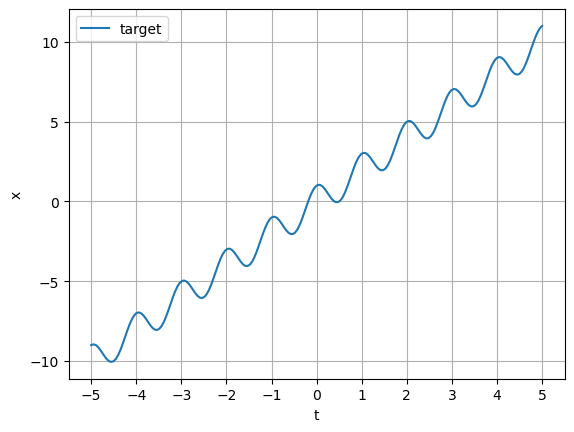

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

#  plot the trajectory
data = np.load("q2_a_data.npy") # size: 200*2, the first column is time input while the second column is x-coordinate.
t = data[:, 0]
target = data[:, 1]

plt.plot(t, target, label='target')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))  # tick interval = 1
plt.legend()
plt.grid()
plt.xlabel("t")
plt.ylabel("x")
plt.show()

### Basis Function Selection and Justification

From the above graph, we can see that trajectory exhibits two key characteristic. First,  there is a clear linear increasing trend. Second, periodic oscillations can be observed which match with pattern of trigonometric basis functions . In this case, a combination of polynomial and sine and cosine basis functions can be selected to model this behaviour.

The linear component is captured using a first-degree polynomial term ( t ), whilst the periodic behaviour is modelled using sine and cosine functions. Moreover, a bias term is included to allow vertical shifting of the function.

The resulting basis function vector is:

##### Basis Function Vector:

$$
\phi(t) = [1,\; t,\; \sin(\omega t),\; \cos(\omega t)]
$$

##### Corresponding Model:

$$
x(t) = w_0 + w_1 t + w_2 \sin(\omega t) + w_3 \cos(\omega t)
$$


Initially, only a sine function was used to represent the oscillatory component. However, this resulted in a poor fit due to a phase mismatch between the model and the data. So  a cosine function was added and the model fit improved noticeably. It means the data contains a phase shift.

This combination provides an accurate fit with a small number of basis functions. Beside that,  a minor Mean Squared Error (MSE)  was achived which proves the correct model selection.


In [66]:
from sklearn.metrics import mean_squared_error

# Choosing frequency from the plot, we can see that the period is approximately 1, so we set omega = 2 * pi / 1
omega = 2 * np.pi / 1.0   # assuming period ≈ 1

# Design matrix with combination of sine, cosine, linear and bias terms
Phi = np.column_stack([
    np.ones_like(t),          # bias
    t,                        # linear trend
    np.sin(omega * t),        # sine term
    np.cos(omega * t)         # cosine term
])

# Computing weights (Normal Equation)
w = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ target

# Predicting the output
y_pred = Phi @ w

# MSE
mse = mean_squared_error(target, y_pred)
print("MSE:", mse)

MSE: 1.4818567215302045e-30


### Plot
For the visualisation the following graph was produced:

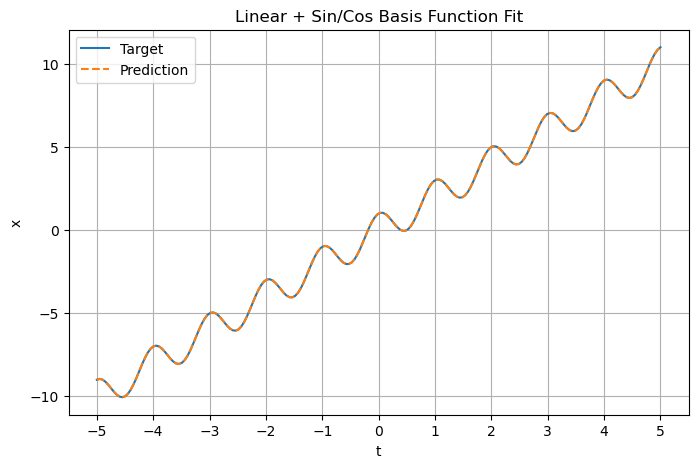

In [67]:
# Plot
plt.figure(figsize=(8,5))
plt.plot(t, target, label='Target')
plt.plot(t, y_pred, '--', label='Prediction')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))

plt.xlabel("t")
plt.ylabel("x")
plt.title("Linear + Sin/Cos Basis Function Fit")
plt.legend()
plt.grid()
plt.show()


**Q2 b (5 marks)**

Similar to Q2 a, please read data from "q2_b_data.npy", and do the following:

1. Choose and implement your basis function combination. You may decide whether to include a bias term depending on your fitting performance.
2. Plot your prediction and the original data in the same figure (i.e., t-x).
3. Calculate and report the Mean Squared Error (MSE) for your fit.
4. Justify your choice of basis functions.

Include clear titles, axis labels, and legends for all figures.

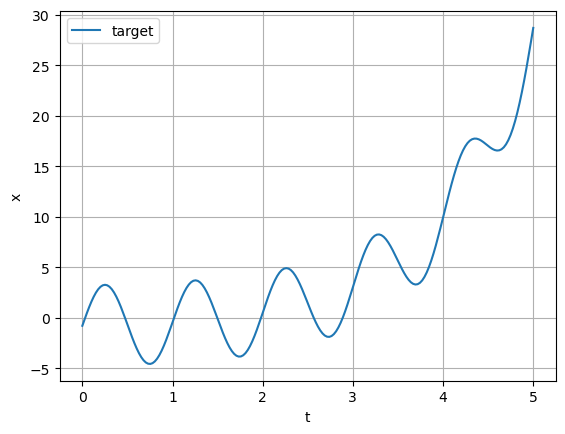

In [68]:
#  plot the trajectory
data = np.load("q2_b_data.npy") # size: 200*2, the first column is time input while the second column is x-coordinate.
t = data[:, 0]
target = data[:, 1]

plt.plot(t, target, label='target')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))  # tick interval = 1
plt.legend()
plt.grid()
plt.xlabel("t")
plt.ylabel("x")
plt.show()

## Choice of Basis Functions

The basis functions were chosen based on the observed behaviour of the data above:

- **Exponential term** $e^{\alpha t}$: captures the overall growth/decay trend  
- **Sine and cosine terms** $\sin(\omega t)$, $\cos(\omega t)$: capture periodic (oscillatory) patterns  
- **Bias term** $1$: allows vertical shifting of the model  

---

## Final Model

$$
y(t) = w_0 + w_1 e^{\alpha t} + w_2 \sin(\omega t) + w_3 \cos(\omega t)
$$

---

### Construct Design Matrix
For each $(\alpha, \omega)$:
$$
\Phi = [1,\ e^{\alpha t},\ \sin(\omega t),\ \cos(\omega t)]
$$

---

### Compute Weights
Weights are estimated using the pseudoinverse:
$$
w = \Phi^{+} y
$$

---

### Make Predictions
$$
\hat{y} = \Phi w
$$

---

### Evaluate Model
We compute Mean Squared Error (MSE):
$$
\text{MSE} = \frac{1}{n} \sum (y - \hat{y})^2
$$

---

### Grid Search
We test multiple values of $\alpha$ and $\omega$ and select the pair that minimises MSE.

---

### Final Model
Using the best parameters:
$$
y(t) = w_0 + w_1 e^{\alpha t} + w_2 \sin(\omega t) + w_3 \cos(\omega t)
$$

---

### Results
- Best $\alpha \approx 0.997$  
- Best $\omega \approx 6.278$  
- Very low MSE → model fits the data well

In [69]:
# load data
data = np.load("q2_b_data.npy")
t = data[:, 0]
y = data[:, 1]

# searching for best alpha and omega
alphas = np.linspace(0.1, 1.5, 40)   # exponential growth
omegas = np.linspace(4, 10, 80)      # frequency

best_mse = float("inf") # initializing best MSE to infinity
best_params = None # to store the best (alpha, omega) pair 
best_w = None

# in t and y, we have 200 data points, so the design matrix Phi will be of shape (200, 4) since we have 4 basis functions: bias, exponential, sine and cosine.
for alpha in alphas:
    for omega in omegas:
        Phi = np.column_stack([   
            np.ones_like(t),
            np.exp(alpha * t), # exponential growth term
            np.sin(omega * t), # sine term
            np.cos(omega * t)  # cosine term
        ])
        
        # solving weights using pseudo-inverse
        w = np.linalg.pinv(Phi) @ y
        y_pred = Phi @ w
         
        mse = mean_squared_error(y, y_pred) # compute MSE for current parameters
        
        if mse < best_mse:  #finding the best parameters based on MSE
            best_mse = mse
            best_params = (alpha, omega)
            best_w = w

# rebuild model with best params
alpha_best, omega_best = best_params

Phi_best = np.column_stack([
    np.ones_like(t),
    np.exp(alpha_best * t), 
    np.sin(omega_best * t),
    np.cos(omega_best * t)
])

y_pred = Phi_best @ best_w # predict using the best model

# print results
print("Best alpha:", alpha_best)
print("Best omega:", omega_best)
print("Best MSE:", best_mse)

Best alpha: 0.9974358974358973
Best omega: 6.2784810126582276
Best MSE: 0.0004821249307333702


### Plot
The fit of our model can be seen in the follwing graph showing original and predicted data together:

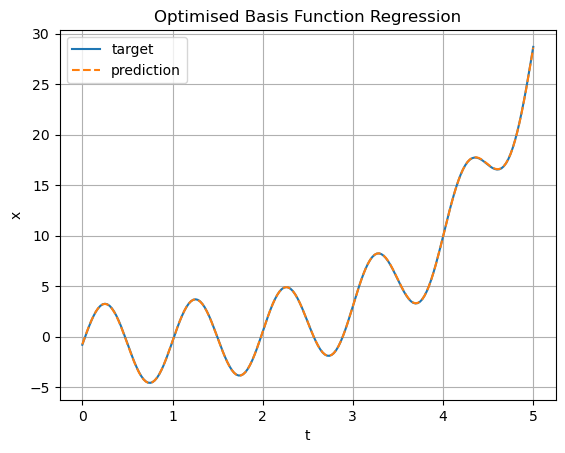

In [70]:
plt.plot(t, y, label="target") # plot original data
plt.plot(t, y_pred, '--',label="prediction") # plot prediction

plt.xlabel("t")
plt.ylabel("x")
plt.title("Optimised Basis Function Regression")
plt.legend()
plt.grid()

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))

plt.show()

# Question 3

**Q3 a (4 marks)**

You are given a data array called "shape_array.npy" that comprises 7 samples organised as columns in the array, where each column corresponds to one sample. The data format in each column is: [x_1, y_1, z_1, x_2, y_2, z_2, ………, x_N, y_N, z_N], where (x_i, y_i, z_i) corresponds to the i-th 3D point of a blood vessel. By plotting all 3D points in one column, you can obtain the shape of a blood vessel of that sample.

Plot seven figures to show the 3D blood vessel shape for each sample separately. Also plot two arbitrary shapes on top of each other to get a feeling of how similar or dissimilar the shapes are.

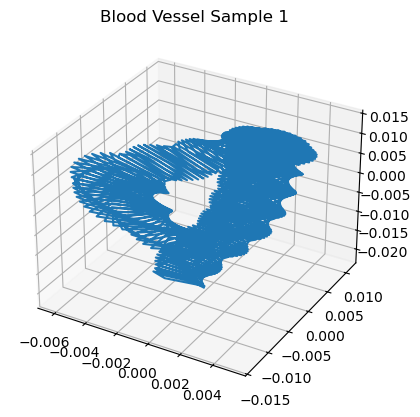

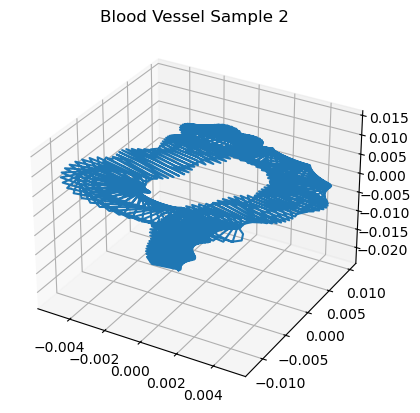

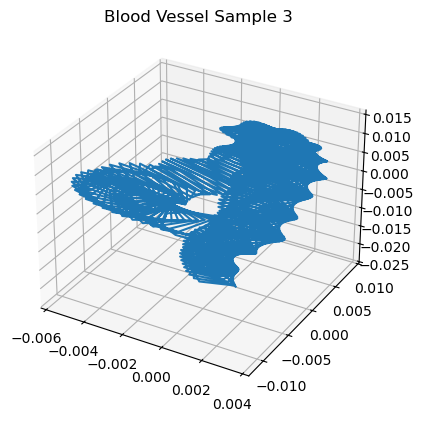

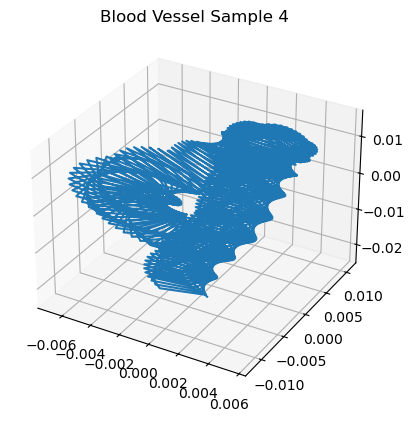

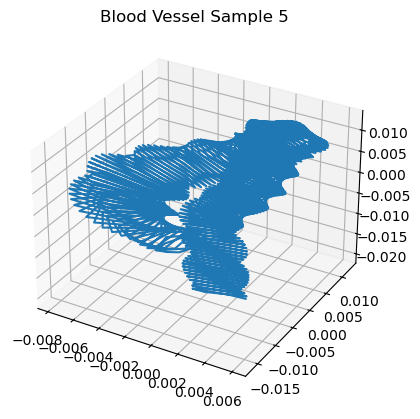

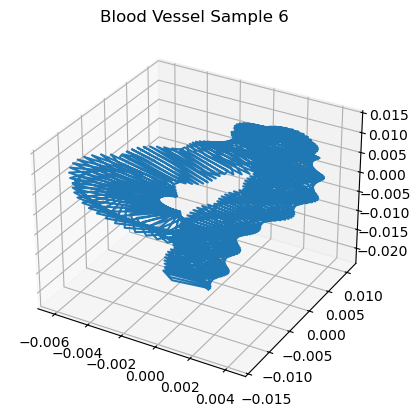

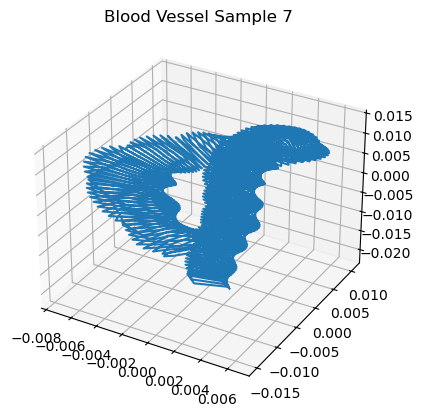

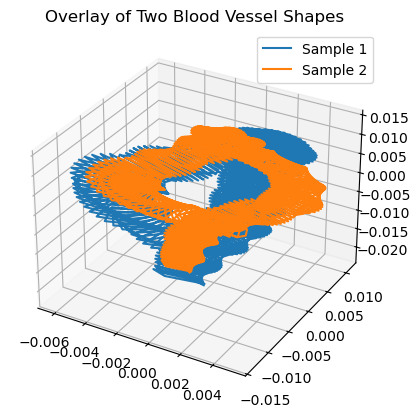

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D plotting toolkit

# load data
data = np.load("shape_array.npy")

num_samples = data.shape[1]  # 7 samples (columns)

# Plotting each blood vessel sample in 3D
for i in range(num_samples):

    sample = data[:, i] # reshape the sample to have 3 columns (x, y, z)
    points = sample.reshape(-1, 3)  # reshaping to (N, 3) where N is the number of points in the blood vessel

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(points[:, 0], points[:, 1], points[:, 2])

    ax.set_title(f"Blood Vessel Sample {i+1}")

    plt.show()


# Overlying two random samples
sample1 = data[:, 0].reshape(-1, 3) 
sample2 = data[:, 1].reshape(-1, 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(sample1[:, 0], sample1[:, 1], sample1[:, 2], label="Sample 1")
ax.plot(sample2[:, 0], sample2[:, 1], sample2[:, 2], label="Sample 2")

ax.set_title("Overlay of Two Blood Vessel Shapes")
ax.legend()

plt.show()

**Q3 b (10 marks)** 

Next, perform eigendecomposition of the covariance matrix estimated from the given data array. Finally, project original data onto lower-dimensional space and reconstruct data.

Proceed as follows:

1. Subtract the mean from the data, so that it is centered around the origin.

2. Estimate the covariance matrix from the centred data.

3. Calculate eigenvectors and eigenvalues using numpy functions

4. Project centered data (1845 dimension) into 5 dimension. 

5. Reconstruct the blood vessel shape from the lower dimension data in step 4.


As a sanity check plot a blood vessel shape reconstructed from the eigenvectors on top of the original blood vessel shape. Comment on your results.

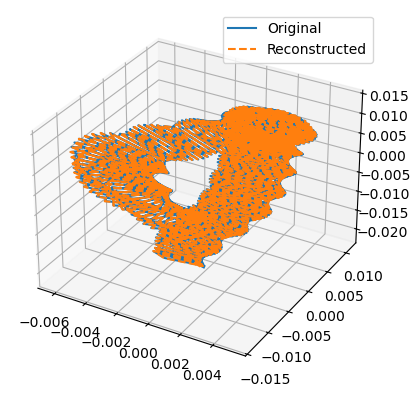

In [78]:
# Mean Centering
mean_shape = np.mean(data, axis=1, keepdims=True)
data_centered = data - mean_shape

# Estimating covariance matrix
cov_matrix = np.cov(data_centered)

# Calculating eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# sort eigenvalues and eigenvectors in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]


# Projecting data onto top k eigenvectors
k = 5
U_k = eigenvectors[:, :k]   # (1845, 5)

projected_data = U_k.T @ data_centered   # (5, 7)

# Reconstructing the data from the projection
reconstructed_data = (U_k @ projected_data) + mean_shape


# Plotting one sample
i = 0

original = data[:, i].reshape(-1, 3)
reconstructed = reconstructed_data[:, i].reshape(-1, 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(original[:,0], original[:,1], original[:,2], label="Original")
ax.plot(reconstructed[:,0], reconstructed[:,1], reconstructed[:,2],
        linestyle='dashed', label="Reconstructed")

ax.legend()
plt.show()

### Summary
The figure shows nearly total overlap between the actual and simulated blood vessel shapes. This suggests that the majority of the dataset's variation is captured by the first five primary components.

The blood vessel forms appear to be in a low-dimensional subspace, which can be effectively described with just a few basis directions, according to a minor reconstruction error.


The discarded lower-variance eigenvectors, which possibly contain a noise or fine-scale features, are responsible for any small variations between the original and reconstructed shapes.

**Q3 c (4 marks)** 

Research PCA analysis using the *scikit-learn* library. Perform PCA analysis and show the reconstructed data of any blood vessel shape on top of the original blood vessel shape. There are variables in the PCA object that correspond to the eigenvalues used for choosing projection eigenvectors. Compare the eigenvalues  and eigenvectors you have computed in the previous question with the eigenvalues  and the eigenvectors computed by the *scikit-learn* library. Compare the reconstructed coordinates from both methods. Comment on your results.

Sklearn eigenvalues:
 [1.1398973e-03 3.8329812e-04 1.4392439e-04 1.1443542e-04 3.1203690e-05
 1.1333163e-05 2.8756419e-16]


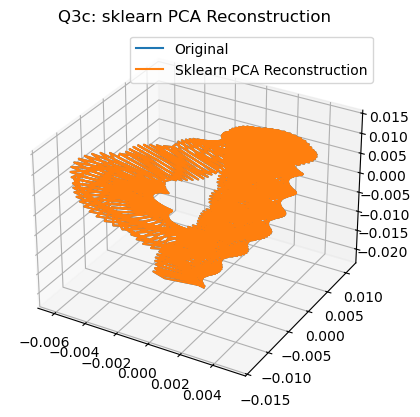


Manual eigenvalues:
 [ 1.13989731e-03  3.83298015e-04  1.43924451e-04 ... -3.62769740e-19
 -3.75501558e-19 -5.79301781e-19]

Sklearn eigenvalues:
 [1.1398973e-03 3.8329812e-04 1.4392439e-04 1.1443542e-04 3.1203690e-05
 1.1333163e-05 2.8756419e-16]


In [81]:
from sklearn.decomposition import PCA

# Transposing
X = data.T

# Applying pca using sklearn
pca = PCA()
X_pca = pca.fit_transform(X)

# eigenvalues + eigenvectors
eigenvalues_sklearn = pca.explained_variance_
eigenvectors_sklearn = pca.components_

print("Sklearn eigenvalues:\n", eigenvalues_sklearn)

# Reconstructing one sample
i = 0  # choosing sample

x_original = X[i]

z = pca.transform(X)
x_reconstructed = pca.inverse_transform(z[i])

# Reshaping to 3D
original_points = x_original.reshape(-1, 3)
recon_points = x_reconstructed.reshape(-1, 3)

# Plotting comparison
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(original_points[:, 0], original_points[:, 1], original_points[:, 2],
        label="Original")

ax.plot(recon_points[:, 0], recon_points[:, 1], recon_points[:, 2],
        label="Sklearn PCA Reconstruction")

ax.set_title("Q3c: sklearn PCA Reconstruction")
ax.legend()

plt.show()

# Comparison of eigenvalues 
print("\nManual eigenvalues:\n", eigenvalues)
print("\nSklearn eigenvalues:\n", eigenvalues_sklearn)

### Summary

From the printed results, it is obvious that the eigenvalues obtained from manual eigendecomposition and sklearn PCA are almost identical for the dominant components. This means  that both methods capture the same variance structure in the data. Minor differences may appear in smaller eigenvalues because of numerical precision. Moreover sklearn uses a more stable SVD-based implementation. The presence of near-zero eigenvalues indicates that the data lies in a lower-dimensional subspace, which in turn shows that dimensionality reduction is effective.